# Métodos de Ensemble en Aprendizaje Supervisado

## ¿Qué es un Ensemble?

Un ensemble es una técnica que combina múltiples modelos (a menudo llamados modelos base o débiles) para obtener un modelo más robusto y preciso.

Ventajas de los ensembles:

- Reducen el riesgo de sobreajuste.

- Mejoran la precisión general.
  
- Son más estables ante variaciones en los datos.

Los dos enfoques principales son:

- **Bagging** (Bootstrap Aggregating)
- **Boosting**

### Bagging

Bagging entrena múltiples modelos en subconjuntos aleatorios (con reemplazo) del conjunto de entrenamiento. Luego combina sus predicciones (por ejemplo, con votación o promedio).

Un ejemplo clásico: **Random Forest**

*Es un ensemble de árboles de decisión entrenados sobre distintos subconjuntos de datos y seleccionando aleatoriamente características en cada división.*

Para ilustrar mejor las ventajas de un Random Forest frente a un único árbol de decisión, usaremos el dataset digits de sklearn (1 797 imágenes de dígitos manuscritos de 8×8 = 64 píxeles → 10 clases).

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()

fig, axes = plt.subplots(1, 10, figsize=(10, 2))
for i, ax in enumerate(axes):
    print(digits.images[i])
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'{digits.target[i]}')
    ax.axis('off')

plt.suptitle("Primeras 10 imágenes del dataset Digits", fontsize=14)
plt.show()


In [ ]:
# ------------------------------------------------------------------
# 1. Carga del dataset y partición train-test
# ------------------------------------------------------------------
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X, y = load_digits(return_X_y=True)
print(f"Nº muestras: {X.shape[0]},  Nº features: {X.shape[1]},  Clases: {len(set(y))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# ------------------------------------------------------------------
# 2. Árbol de decisión “solo”
# ------------------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("=== Árbol de decisión ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(classification_report(y_test, y_pred_dt))

# ------------------------------------------------------------------
# 3. Random Forest
# ------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,          # nº de árboles
    max_depth=None,           # sin límite, pero…
    n_jobs=-1,                # usa todos los cores
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf))


Nº muestras: 1797,  Nº features: 64,  Clases: 10
=== Árbol de decisión ===
Accuracy: 0.852
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        54
           1       0.87      0.71      0.78        55
           2       0.78      0.81      0.80        53
           3       0.91      0.91      0.91        55
           4       0.85      0.87      0.86        54
           5       0.89      0.87      0.88        55
           6       0.96      0.89      0.92        54
           7       0.89      0.91      0.90        54
           8       0.72      0.83      0.77        52
           9       0.75      0.81      0.78        54

    accuracy                           0.85       540
   macro avg       0.86      0.85      0.85       540
weighted avg       0.86      0.85      0.85       540

=== Random Forest ===
Accuracy: 0.965
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        54
   

**Intuición clave**: promediando muchos modelos de alta varianza (árboles profundos con distintos subconjuntos de datos/atributos) se reduce la varianza total, obteniendo predicciones más estables y precisas.

**¿Por qué el arbol de decisión sobreaprende?**

Un árbol de decisión intenta dividir el espacio de características para separar perfectamente las clases en el conjunto de entrenamiento, siguiendo reglas como "si píxel 32 > 5, ir a la derecha". Cada nodo busca la división más pura posible.

El árbol puede crear muchas ramas que memoricen patrones muy específicos del set de entrenamiento; ajustar reglas como “si píxel 17 es exactamente 15 y píxel 3 es 2… entonces es un 4”; lo que no generaliza bien a nuevos datos.

## Boosting

Gradient Boosting entrena una secuencia de modelos débiles (usualmente árboles pequeños) que se corrigen unos a otros. Cada nuevo modelo intenta corregir los errores del modelo anterior.

Un algoritmo muy popular es Gradient Boosting.

Accuracy: 0.975925925925926

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.96      1.00      0.98        50
           2       1.00      0.98      0.99        47
           3       1.00      0.98      0.99        54
           4       0.98      0.98      0.98        60
           5       1.00      0.97      0.98        66
           6       0.98      0.96      0.97        53
           7       0.96      0.98      0.97        55
           8       0.91      1.00      0.96        43
           9       0.96      0.93      0.95        59

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



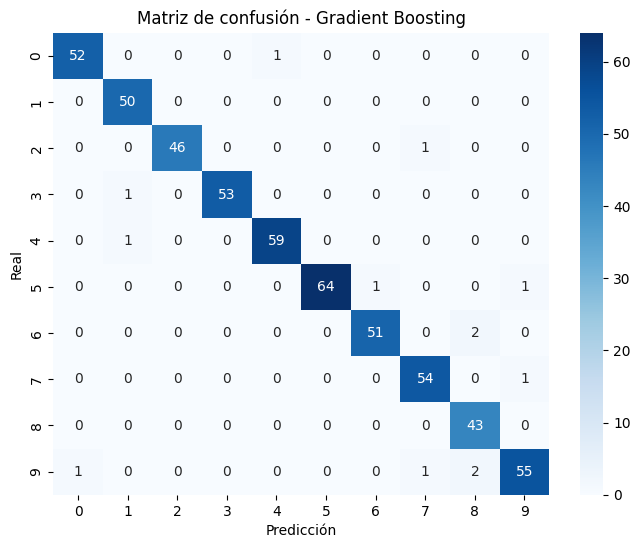

In [ ]:
from sklearn.datasets import load_digits
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar datos
digits = load_digits()
X, y = digits.data, digits.target

# 2. Separar en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Modelo Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

# 4. Predicción
y_pred = gb.predict(X_test)

# 5. Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# 6. Matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Gradient Boosting")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


Gradient Boosting tiene resultados similares o a veces mejor que Random Forest.

#### Paso a paso con código y explicación

In [ ]:
from sklearn.datasets import load_digits
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataset
digits = load_digits()
X, y = digits.data, digits.target

# 2. Reducimos a solo 3 clases para ilustrar mejor (digamos dígitos 0, 1 y 2)
idx = y < 3
X_small, y_small = X[idx], y[idx]

# 3. Dividimos en train y test
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.3, random_state=42)

# 4. Entrenamos un modelo Gradient Boosting muy simple para seguir su evolución
gb = GradientBoostingClassifier(n_estimators=5, learning_rate=0.1, max_depth=2)
gb.fit(X_train, y_train)


GradientBoostingClassifier(max_depth=2, n_estimators=5)

El modelo GradientBoostingClassifier con n_estimators=5 entrena 5 árboles secuenciales, cada uno para corregir los errores del anterior.

Vamos a ilustrar cómo cambia la probabilidad predicha para una imagen específica después de cada árbol.

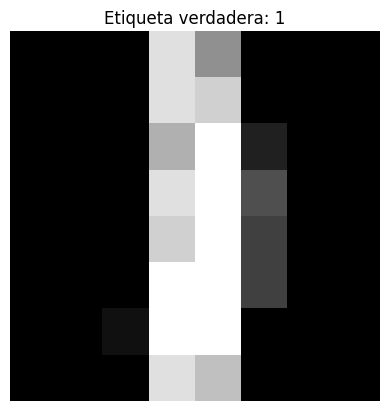

In [ ]:
# Elegimos una imagen de test
i = 0
x_sample = X_test[i].reshape(1, -1)
y_true = y_test[i]

# Vemos la imagen
plt.imshow(x_sample.reshape(8, 8), cmap="gray")
plt.title(f"Etiqueta verdadera: {y_true}")
plt.axis("off")
plt.show()


Usamos el método staged_predict_proba, que da las predicciones después de cada árbol.

In [ ]:
# Obtenemos predicciones de probabilidad después de cada etapa
proba_per_stage = list(gb.staged_predict_proba(x_sample))

# Imprimimos cómo cambia la probabilidad de cada clase
for stage, probs in enumerate(proba_per_stage):
    print(f"Etapa {stage+1}: Probabilidades predichas")
    for cls, p in enumerate(probs[0]):
        print(f"  Clase {cls}: {p:.4f}")
    print()


Etapa 1: Probabilidades predichas
  Clase 0: 0.3020
  Clase 1: 0.3956
  Clase 2: 0.3024

Etapa 2: Probabilidades predichas
  Clase 0: 0.2640
  Clase 1: 0.4501
  Clase 2: 0.2859

Etapa 3: Probabilidades predichas
  Clase 0: 0.2319
  Clase 1: 0.5014
  Clase 2: 0.2667

Etapa 4: Probabilidades predichas
  Clase 0: 0.1956
  Clase 1: 0.5247
  Clase 2: 0.2797

Etapa 5: Probabilidades predichas
  Clase 0: 0.1722
  Clase 1: 0.5674
  Clase 2: 0.2603



Cada árbol no predice una clase directamente. En realidad, cada árbol ajusta las probabilidades predichas, calculando un “gradiente del error” (de la función log-loss) para cada clase. Así, el modelo mejora iterativamente las probabilidades.

Los árboles usados en Gradient Boosting no son clasificadores, sino árboles de regresión. Cada árbol predice un valor numérico continuo (no una clase), y su tarea es corregir el error (residual) del modelo anterior.